In [42]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


Este notebook demonstra um fluxo de trabalho básico de Machine Learning usando o algoritmo Support Vector Machine (SVM) para classificação[cite: 1]. Ele cobre desde a importação das bibliotecas necessárias até a avaliação do modelo[cite: 1]. Atendendo aos requisitos da atividade, os dados são obtidos diretamente do repositório do Kaggle, incluindo uma etapa de Análise Exploratória de Dados (EDA).

### **1. Importação de Bibliotecas**

Primeiramente, importamos as bibliotecas essenciais para a construção e avaliação do modelo[cite: 1]:
*   `sklearn.model_selection.train_test_split`: Para dividir os dados em conjuntos de treino e teste[cite: 1].
*   `sklearn.svm.SVC`: A classe para o classificador Support Vector Machine[cite: 1].
*   `sklearn.metrics`: Para calcular a acurácia do modelo, relatório de classificação e matriz de confusão[cite: 1].
*   `matplotlib` e `seaborn`: Para visualização gráfica dos dados e dos resultados.

In [43]:
# Importação das bibliotecas complementares de Machine Learning e visualização
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### **2. Carregamento e Preparação dos Dados (EDA)**

Nesta etapa, carregamos o famoso conjunto de dados Iris, que contém medidas de três espécies de flores de Íris[cite: 1]. Como exigido pela atividade, utilizaremos o arquivo CSV do Kaggle e faremos uma análise exploratória para entender a distribuição.

In [44]:
# O caminho do arquivo foi listado no output da Célula 1
# Carregando o CSV usando o pandas
df = pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv')

# Exibindo as primeiras linhas e as informações técnicas do dataset
display(df.head())
print("\nInformações do Dataset:")
df.info()

print("\nVerificando valores nulos:")
print(df.isnull().sum())

print("\nDistribuição das classes:")
print(df['Species'].value_counts())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Verificando valores nulos:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Distribuição das classes:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


Podemos notar que o dataset está perfeitamente balanceado, com 50 amostras por espécie, e não possui valores nulos. Para a análise visual, vamos gerar um gráfico de dispersão pareada.

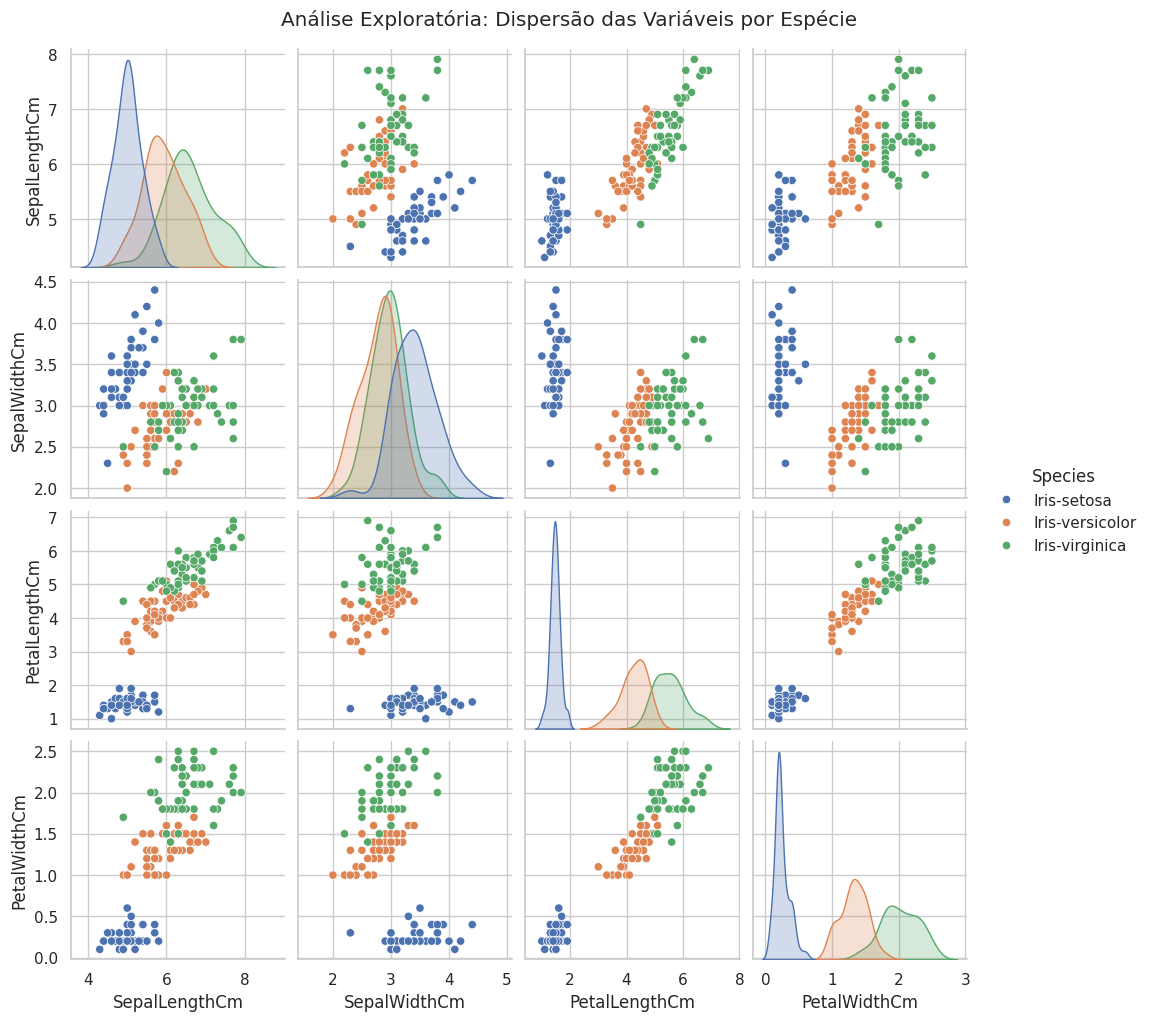

In [45]:
# Visualização exploratória (EDA) das características das flores
# A coluna 'Id' é descartada aqui apenas para o gráfico, pois é apenas um índice
sns.pairplot(df.drop(columns=['Id']), hue='Species', height=2.5)
plt.suptitle('Análise Exploratória: Dispersão das Variáveis por Espécie', y=1.02)
plt.show()

### **3. Divisão dos Dados em Treino e Teste**

Separamos as características (`X`) dos rótulos (`y`), que representam as espécies de flores[cite: 1]. É crucial dividir os dados em dois subconjuntos: treino e teste[cite: 1]. O conjunto de treino é usado para ensinar o modelo, e o conjunto de teste é usado para avaliar seu desempenho em dados que ele nunca viu antes, garantindo que o modelo generalize bem[cite: 1].

*   `test_size=0.2`: 20% dos dados serão usados para teste[cite: 1].
*   `random_state=42`: Garante que a divisão seja a mesma cada vez que o código for executado, tornando os resultados reproduzíveis[cite: 1].

In [46]:
# Preparação dos dados: remoção da coluna Id e separação das features (X) e rótulos (y)
X = df.drop(columns=['Id', 'Species'])  # As características (features)
y = df['Species']                       # Os rótulos (labels)

# Divida os dados em conjunto de treino e teste (80% treino, 20% teste)[cite: 1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **4. Criação e Treinamento do Modelo SVM**

Inicializamos o classificador Support Vector Machine (`SVC`) com um kernel linear (`kernel='linear'`)[cite: 1]. O kernel linear é adequado para dados que podem ser separados linearmente[cite: 1]. Em seguida, treinamos o modelo usando os dados de treino (`X_train` e `y_train`)[cite: 1]. Durante esta fase, o algoritmo SVM aprende a melhor fronteira de decisão para classificar as diferentes espécies de Iris[cite: 1].

In [47]:
# Criando o modelo SVM
model = SVC(kernel='linear')

# Treinando o modelo com os dados de treino
model.fit(X_train, y_train)

SVC(kernel='linear')

### **5. Previsão com o Modelo Treinado**

Após o treinamento, usamos o modelo para fazer previsões nos dados de teste (`X_test`)[cite: 1]. O modelo aplica o que aprendeu para prever as espécies de Iris para cada amostra no conjunto de teste[cite: 1].

In [48]:
# Fazendo as previsões nos dados de teste
y_pred = model.predict(X_test)

### **6. Avaliação do Modelo**

Calculamos a acurácia do modelo comparando as previsões (`y_pred`) com os rótulos verdadeiros do conjunto de teste (`y_test`)[cite: 1]. A acurácia é a proporção de previsões corretas em relação ao total de previsões[cite: 1]. Para uma inspeção visual, imprimimos os valores preditos pelo modelo e os valores reais do conjunto de teste[cite: 1].

In [49]:
# Calculando a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia do modelo: {accuracy * 100:.2f}%\n')

# Mostrando a previsão e os valores verdadeiros
print("Valores preditos:")
print(y_pred)
print("\nValores reais:")
print(y_test.values)

Acurácia do modelo: 100.00%

Valores preditos:
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']

Valores reais:
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris

### **7. Matriz de Confusão e Importância das Features**

Para a visualização da matriz de forma gráfica podemos utilizar a biblioteca matplotlib e seaborn[cite: 1]. Isso permite enxergar rapidamente possíveis erros e falsos positivos do classificador. Adicionalmente, analisamos a importância de cada variável de entrada por meio da magnitude dos coeficientes do SVM.

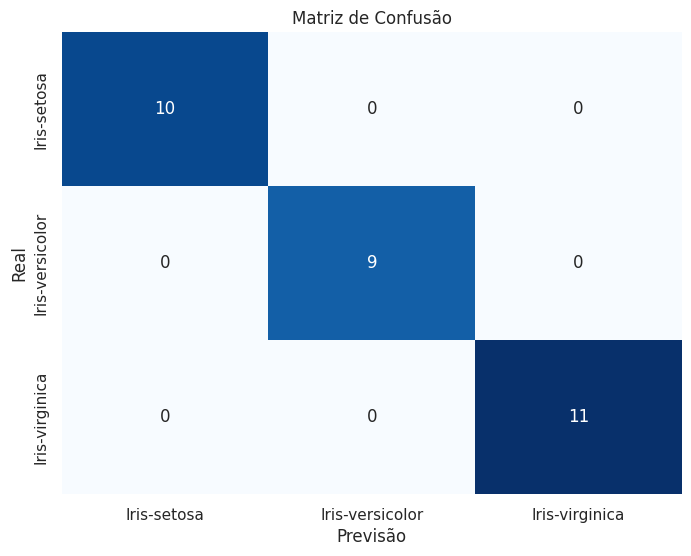

In [50]:
# Gerando a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
# Plotando a matriz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

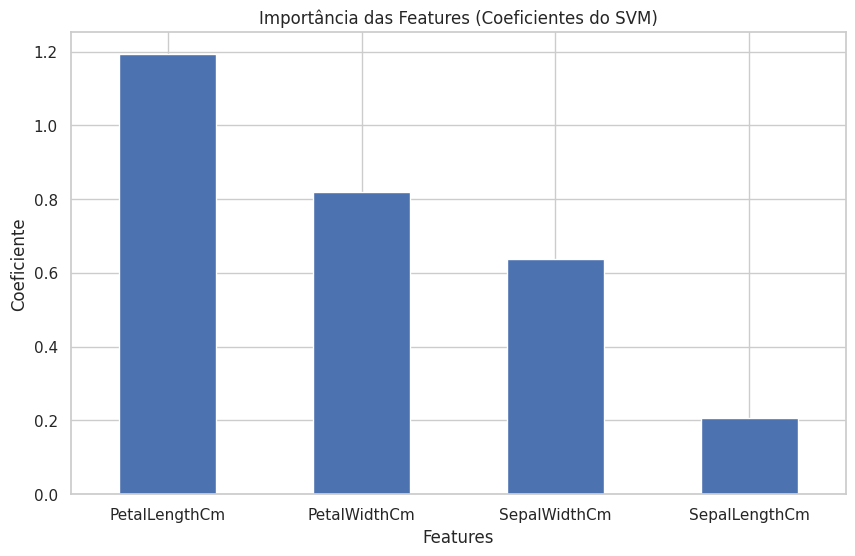

In [51]:
# Importância das Features
# A magnitude absoluta do coeficiente indica o peso da característica nas fronteiras de decisão
feature_importance = pd.Series(np.mean(np.abs(model.coef_), axis=0), index=X.columns)

plt.figure(figsize=(10, 6))
feature_importance.sort_values(ascending=False).plot(kind='bar')
plt.title('Importância das Features (Coeficientes do SVM)')
plt.xlabel('Features')
plt.ylabel('Coeficiente')
plt.xticks(rotation=0)
plt.show()